In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

df_review_order = pd.read_csv("../data/analysis/review_order_summary.csv")
df_review_order.head(10)

In [ ]:
# データ構造を確認
df_review_order.info()

In [ ]:
# データの基本統計量を確認
df_review_order.describe()

In [ ]:
# レビュー点数ごとの件数
df_review_order["review_score"].value_counts().sort_index()


In [27]:
# レビュー点数別の平均値
avg_score_by_review = (
    df_review_order.groupby("review_score")
    .agg(
        order_count=("order_id", "count"),
        avg_order_price=("total_price", "mean"),
        avg_order_freight=("total_freight", "mean"),
    )
    .reset_index()
)
avg_score_by_review

,review_score,order_count,avg_order_price,avg_order_freight
0,1.0,10778,166.972587,27.749845
1,2.0,3071,145.667105,26.279326
2,3.0,8117,127.544890,23.570729
3,4.0,19012,132.463578,22.372474
4,5.0,56939,134.640429,21.715167


In [ ]:

# 欠損地の確認
df_review_order.isnull().sum()

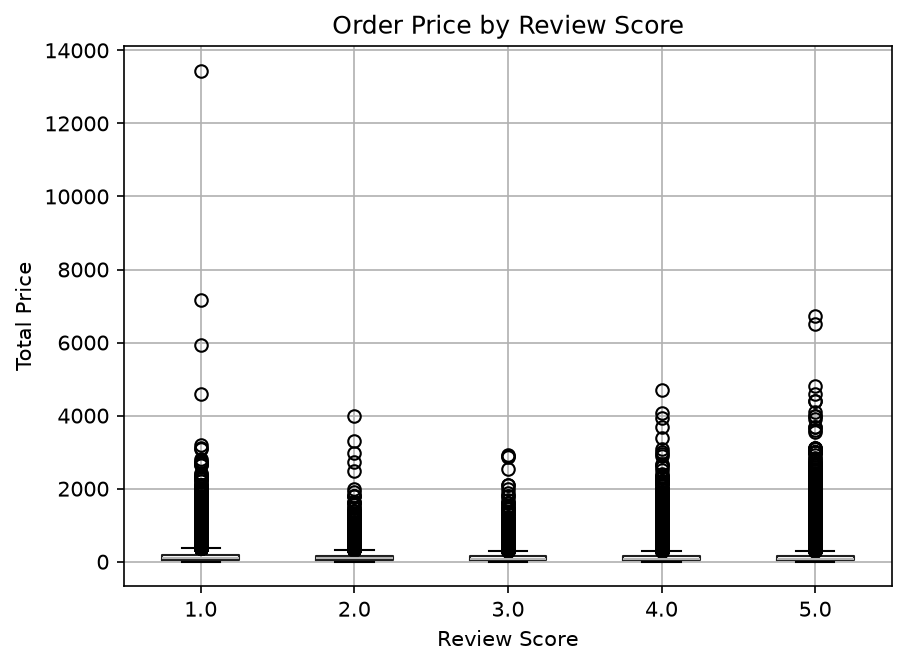

In [ ]:
# レビュー点数別の注文金額を箱ひげ図で確認
df_review_order.boxplot(
    
    column="total_price", 
    by="review_score"
    )

#plt.yscale("log")  # y軸を対数スケールに設定
plt.title("Order Price by Review Score")
plt.suptitle("")  # デフォルトのタイトルを削除
plt.xlabel("Review Score")
plt.ylabel("Total Price")
plt.show()

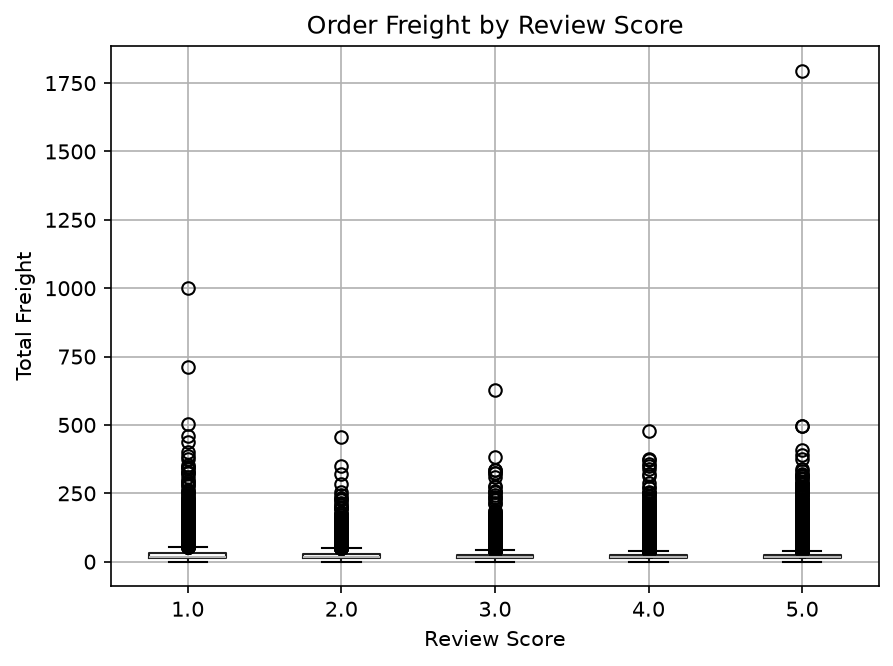

In [17]:
# 送料の箱ひげ図

df_review_order.boxplot(
    column="total_freight",
    by="review_score"
)

plt.title("Order Freight by Review Score")
plt.suptitle("")
plt.xlabel("Review Score")
plt.ylabel("Total Freight")
plt.show()

In [ ]:
from scipy.stats import kruskal

# total_priceの分布がレビュー点数ごとに異なるかどうかを検定
price_groups = [
    df_review_order.loc[df_review_order["review_score"] == score, "total_price"]
    for score in sorted(df_review_order["review_score"].unique())
]

price_result = kruskal(*price_groups)

price_result

KruskalResult(statistic=np.float64(299.1710287802128), pvalue=np.float64(1.635383924953464e-63))

In [21]:
# total_freightの分布がレビュー点数ごとに異なるかどうかを検定
freight_groups = [
    df_review_order.loc[df_review_order["review_score"] == score, "total_freight"]
    for score in sorted(df_review_order["review_score"].unique())
]

freight_result = kruskal(*freight_groups)

freight_result

KruskalResult(statistic=np.float64(932.2901611807529), pvalue=np.float64(1.679637309542234e-200))

In [22]:
print("=== Kruskal-Wallis Test ===")

print("\n[Total Price]")
print(f"H-statistic: {price_result.statistic:.4f}")
print(f"p-value: {price_result.pvalue:.6g}")

print("\n[Total Freight]")
print(f"H-statistic: {freight_result.statistic:.4f}")
print(f"p-value: {freight_result.pvalue:.6g}")

=== Kruskal-Wallis Test ===

[Total Price]
H-statistic: 299.1710
p-value: 1.63538e-63

[Total Freight]
H-statistic: 932.2902
p-value: 1.67964e-200
